# Explainable AI Lab: Local Explanations with **LIME**
### Dataset: Breast Cancer Wisconsin (Diagnostic) — UCI Machine Learning Repository (ID = 17)



---

## Learning Objectives

By the end of this notebook you should be able to:

1. Load a benchmark dataset directly from the **UCI ML Repository** and prepare it for modelling.
2. Train and evaluate a **black-box classifier** (Random Forest) against an interpretable baseline (Logistic Regression).
3. Explain the **mathematical formulation** of LIME (Local Interpretable Model-agnostic Explanations).
4. Generate and *correctly read* **local explanations** for individual predictions.
5. Diagnose **misclassifications** using explanations rather than guesswork.
6. Assess the **local fidelity** and **stability** of an explanation — the two properties most students forget to check.
7. Articulate the **limitations** of LIME and how it compares with SHAP.

## Prerequisites
Python, `numpy`/`pandas`, basic supervised learning, elementary linear algebra and probability.

## 1. Motivation — The Black-Box Problem

A Random Forest with 500 trees may achieve 96% accuracy on cancer diagnosis, but a clinician cannot act on
"the ensemble said malignant". Regulations such as the EU GDPR *right to explanation* and, in India,
the DPDP Act's transparency obligations, make this a practical engineering requirement, not a philosophical one.

Interpretability methods split along two axes:

| Axis | Option A | Option B |
|---|---|---|
| **Scope** | **Global** — how the model behaves overall (e.g. permutation importance) | **Local** — why *this one* prediction was made (LIME, SHAP) |
| **Coupling** | **Model-specific** — needs internals (tree paths, gradients) | **Model-agnostic** — only needs `predict_proba` |

> **LIME is local + model-agnostic.** It answers: *"Which features pushed the model towards this label, for this particular patient?"*

A high global importance for `worst area` does **not** mean `worst area` drove *this* patient's prediction.
That gap is exactly why local methods exist.

In [1]:
# Run once if the packages are missing. Restart the kernel afterwards.
# !pip install -q lime ucimlrepo scikit-learn pandas matplotlib seaborn

In [2]:
import warnings, sys
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)

import lime
import lime.lime_tabular

SEED = 42
np.random.seed(SEED)

%matplotlib inline
plt.rcParams["figure.dpi"] = 110
sns.set_theme(style="whitegrid")

print("Python      :", sys.version.split()[0])
print("NumPy       :", np.__version__)
print("pandas      :", pd.__version__)
import sklearn; print("scikit-learn:", sklearn.__version__)
print("LIME        :", lime.__version__ if hasattr(lime, "__version__") else "installed")

Python      : 3.10.11
NumPy       : 1.26.4
pandas      : 2.3.3
scikit-learn: 1.7.2
LIME        : installed


## 2. The Dataset — Breast Cancer Wisconsin (Diagnostic)

| Property | Value |
|---|---|
| UCI ID | **17** |
| Instances | 569 |
| Features | 30 numeric, real-valued |
| Target | Diagnosis: **M** = malignant, **B** = benign |
| Missing values | None |
| Task | Binary classification |

Features are computed from a digitised image of a **fine needle aspirate (FNA)** of a breast mass.
Ten base measurements are taken for each cell nucleus — *radius, texture, perimeter, area, smoothness,
compactness, concavity, concave points, symmetry, fractal dimension* — and for each of these the
**mean**, **standard error** and **worst** (mean of the three largest values) are recorded, giving 10 × 3 = 30 features.

**Encoding convention used throughout this notebook:** `1 = Malignant` (the positive / clinically important class),
`0 = Benign`. Note that scikit-learn's bundled copy uses the *opposite* convention, so we invert it for consistency.

In [3]:
def load_uci_breast_cancer(verbose=True):
    # Primary path : fetch live from the UCI ML Repository via the official `ucimlrepo` API.
    # Fallback path: identical copy bundled with scikit-learn (for offline / firewalled labs).
    # Returns: X (DataFrame), y (1 = Malignant), feature_names, class_names, source
    try:
        from ucimlrepo import fetch_ucirepo
        ds = fetch_ucirepo(id=17)                 # 17 = Breast Cancer Wisconsin (Diagnostic)
        X = ds.data.features.copy()
        y_raw = ds.data.targets.iloc[:, 0]
        y = (y_raw.astype(str).str.upper().str[0] == "M").astype(int).to_numpy()
        source = "UCI ML Repository (live fetch, id=17)"
        if verbose:
            print(ds.metadata["name"], "|", ds.metadata["abstract"][:90], "...")
    except Exception as e:
        from sklearn.datasets import load_breast_cancer
        if verbose:
            print(f"[!] Live UCI fetch unavailable ({type(e).__name__}). "
                  f"Falling back to the identical scikit-learn copy.")
        d = load_breast_cancer(as_frame=True)
        X = d.data.copy()
        y = 1 - d.target.to_numpy()               # invert: sklearn uses 0=malignant
        source = "scikit-learn bundled copy of UCI dataset 17"

    X.columns = [c.strip() for c in X.columns]
    return X, y, list(X.columns), ["Benign", "Malignant"], source


X, y, feature_names, class_names, SOURCE = load_uci_breast_cancer()

print("\nSource     :", SOURCE)
print("Shape      :", X.shape)
print("Classes    :", dict(zip(class_names, np.bincount(y))))
print("Malignant %: {:.1f}%".format(100 * y.mean()))
X.head()

[!] Live UCI fetch unavailable (ModuleNotFoundError). Falling back to the identical scikit-learn copy.

Source     : scikit-learn bundled copy of UCI dataset 17
Shape      : (569, 30)
Classes    : {'Benign': 357, 'Malignant': 212}
Malignant %: 37.3%


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
# Quick sanity checks — always do these before modelling
print("Missing values :", int(X.isna().sum().sum()))
print("Duplicate rows :", int(X.duplicated().sum()))
print("Dtypes         :", set(map(str, X.dtypes)))

display(X.iloc[:, :6].describe().T.round(3))

Missing values : 0
Duplicate rows : 0
Dtypes         : {'float64'}


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127,3.524,6.981,11.700,13.370,15.780,28.110
mean texture,569.0,19.290,4.301,9.710,16.170,18.840,21.800,39.280
mean perimeter,569.0,91.969,24.299,43.790,75.170,86.240,104.100,188.500
mean area,569.0,654.889,351.914,143.500,420.300,551.100,782.700,2501.000
mean smoothness,569.0,0.096,0.014,0.053,0.086,0.096,0.105,0.163
mean compactness,569.0,0.104,0.053,0.019,0.065,0.093,0.130,0.345


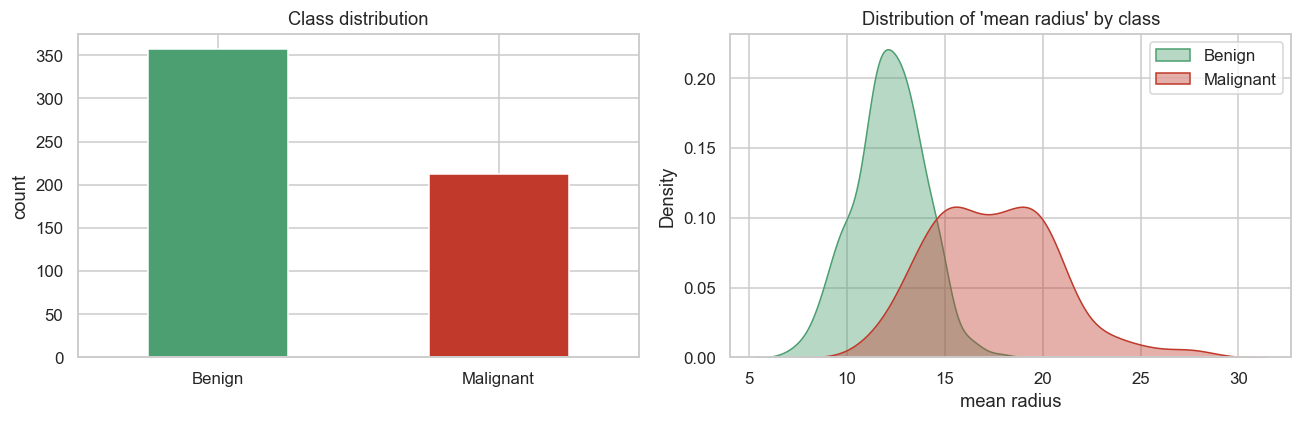

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# (a) class balance
pd.Series(y).map({0: "Benign", 1: "Malignant"}).value_counts().plot(
    kind="bar", ax=axes[0], color=["#4C9F70", "#C0392B"], rot=0)
axes[0].set_title("Class distribution"); axes[0].set_ylabel("count")

# (b) one discriminative feature
col = feature_names[0]   # 'mean radius' / 'radius1'
for lab, name, c in [(0, "Benign", "#4C9F70"), (1, "Malignant", "#C0392B")]:
    sns.kdeplot(X.loc[y == lab, col], ax=axes[1], fill=True, alpha=.4, label=name, color=c)
axes[1].set_title(f"Distribution of '{col}' by class"); axes[1].legend()
plt.tight_layout(); plt.show()

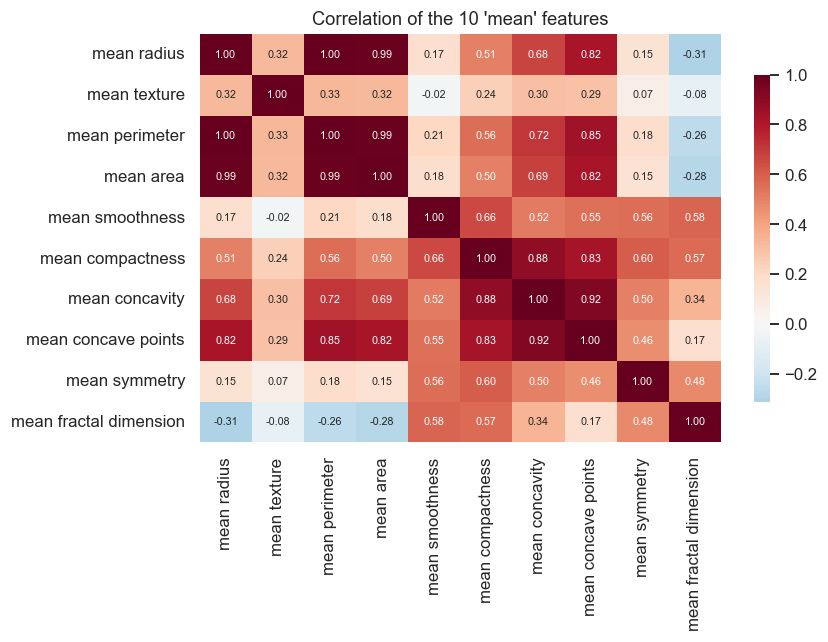

In [6]:
# Correlation among the first 10 (the "mean") features — note the strong block structure.
plt.figure(figsize=(8, 6))
sns.heatmap(X.iloc[:, :10].corr(), cmap="RdBu_r", center=0, annot=True,
            fmt=".2f", annot_kws={"size": 7}, cbar_kws={"shrink": .8})
plt.title("Correlation of the 10 'mean' features")
plt.tight_layout(); plt.show()

> **Observation to carry forward.** `radius`, `perimeter` and `area` are almost perfectly correlated
> (r ≈ 0.99) — they are geometrically redundant. **Correlated features are LIME's known weak spot**:
> credit for a prediction gets split arbitrarily among them, and perturbation generates unrealistic
> synthetic points (a cell with a large radius but tiny area). Keep this in mind in Section 9.

## 3. Train / Test Split and a Critical Design Decision

**Where should the scaler live?**

LIME perturbs data **in the feature space you hand to the explainer** and reports weights in
those same units. If you scale first and pass standardised data, every explanation reads
`worst area <= -0.42` — meaningless to a clinician.

✅ **Correct pattern:** keep the scaler *inside* an sklearn `Pipeline`, give LIME the **raw** training data,
and pass `pipeline.predict_proba` as the prediction function. The pipeline scales internally; the
explanation stays in original units (mm, µm², …).

Tree ensembles do not need scaling at all, so our Random Forest consumes raw features directly.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y)

print(f"Train: {X_train.shape[0]} samples  ({100*y_train.mean():.1f}% malignant)")
print(f"Test : {X_test.shape[0]} samples  ({100*y_test.mean():.1f}% malignant)")

# LIME works on NumPy arrays
X_train_np = X_train.to_numpy()
X_test_np  = X_test.to_numpy()

Train: 426 samples  (37.3% malignant)
Test : 143 samples  (37.1% malignant)


## 4. Models: an Interpretable Baseline vs. a Black Box

We deliberately train two models:

* **Logistic Regression** — *intrinsically interpretable*. Its coefficients ARE a global explanation.
  This is our reference point; if it matched the Random Forest's accuracy we would not need LIME at all.
* **Random Forest (400 trees)** — *black box*. No single coefficient exists; the decision is spread
  over thousands of split conditions. This is the model we will explain.

In [8]:
logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000, random_state=SEED))
])

rf = RandomForestClassifier(
    n_estimators=400, max_depth=None, min_samples_leaf=2,
    n_jobs=-1, random_state=SEED)

logreg.fit(X_train_np, y_train)
rf.fit(X_train_np, y_train)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
for name, model in [("Logistic Regression", logreg), ("Random Forest", rf)]:
    s = cross_val_score(model, X_train_np, y_train, cv=cv, scoring="roc_auc")
    print(f"{name:22s}  5-fold CV ROC-AUC = {s.mean():.4f} (+/- {s.std():.4f})")

Logistic Regression     5-fold CV ROC-AUC = 0.9914 (+/- 0.0090)
Random Forest           5-fold CV ROC-AUC = 0.9874 (+/- 0.0089)


In [9]:
def evaluate(model, name):
    y_pred  = model.predict(X_test_np)
    y_proba = model.predict_proba(X_test_np)[:, 1]
    print(f"\n{'='*58}\n{name}\n{'='*58}")
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}\n")
    print(classification_report(y_test, y_pred, target_names=class_names, digits=3))
    return y_pred, y_proba

_,        proba_lr = evaluate(logreg, "Logistic Regression (interpretable baseline)")
y_pred_rf, proba_rf = evaluate(rf,    "Random Forest (black box -> to be explained)")


Logistic Regression (interpretable baseline)
Accuracy : 0.9650
ROC-AUC  : 0.9962

              precision    recall  f1-score   support

      Benign      0.957     0.989     0.973        90
   Malignant      0.980     0.925     0.951        53

    accuracy                          0.965       143
   macro avg      0.968     0.957     0.962       143
weighted avg      0.966     0.965     0.965       143


Random Forest (black box -> to be explained)
Accuracy : 0.9650
ROC-AUC  : 0.9960

              precision    recall  f1-score   support

      Benign      0.947     1.000     0.973        90
   Malignant      1.000     0.906     0.950        53

    accuracy                          0.965       143
   macro avg      0.974     0.953     0.962       143
weighted avg      0.967     0.965     0.965       143



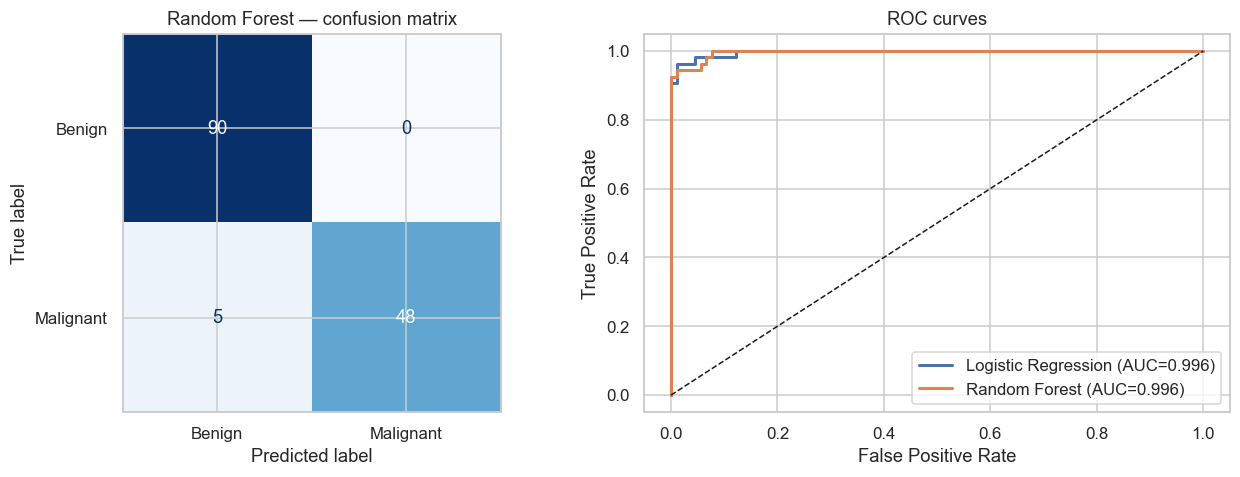

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf),
                       display_labels=class_names).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Random Forest — confusion matrix")

for nm, pr in [("Logistic Regression", proba_lr), ("Random Forest", proba_rf)]:
    fpr, tpr, _ = roc_curve(y_test, pr)
    axes[1].plot(fpr, tpr, lw=2, label=f"{nm} (AUC={roc_auc_score(y_test, pr):.3f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC curves"); axes[1].legend(loc="lower right")

plt.tight_layout(); plt.show()

> In a screening context a **false negative** (malignant predicted benign) is far costlier than a false
> positive. Note the recall on the *Malignant* row above — that, not accuracy, is the number that matters.
> In Section 7 we will use LIME to interrogate exactly these errors.

## 5. How LIME Works — The Theory

### 5.1 Core idea
A complex decision boundary $f$ can be wildly non-linear **globally**, yet be well approximated by a
**straight line in a small neighbourhood** of a single point $x$. LIME fits that local line.

### 5.2 The optimisation problem

$$\xi(x) \;=\; \underset{g \in G}{\arg\min}\; \mathcal{L}\big(f,\, g,\, \pi_x\big) \;+\; \Omega(g)$$

| Symbol | Meaning |
|---|---|
| $f$ | the black-box model (Random Forest); we only query `f.predict_proba` |
| $G$ | class of interpretable models — here **sparse linear regression** |
| $g \in G$ | the local surrogate we fit and show to the user |
| $\pi_x(z)$ | proximity kernel weighting a perturbed sample $z$ by closeness to $x$ |
| $\mathcal{L}$ | weighted squared loss between $f(z)$ and $g(z')$ — the **infidelity** |
| $\Omega(g)$ | complexity penalty — here "use at most $K$ features" (via LASSO path) |

The **exponential kernel** with width $\sigma$:

$$\pi_x(z) \;=\; \exp\!\left(-\,\frac{D(x, z)^2}{\sigma^{2}}\right)$$

and the loss actually minimised:

$$\mathcal{L}(f, g, \pi_x) \;=\; \sum_{z, z' \in \mathcal{Z}} \pi_x(z)\,\big(f(z) - g(z')\big)^{2}$$

### 5.3 Algorithm (tabular data)

1. **Perturb** — draw $N$ (default 5000) synthetic samples around $x$ by sampling each feature from
   $\mathcal{N}(\mu_j, \sigma_j)$ estimated on the training set, then re-centre on $x$.
2. **Label** — query the black box: $f(z)$ for every synthetic sample. *This is the only access LIME needs.*
3. **Weight** — compute $\pi_x(z)$; samples near $x$ dominate the fit.
4. **Select** — pick $K$ features (forward selection / LASSO path).
5. **Fit** — weighted ridge regression of $f(z)$ on the $K$ features.
6. **Report** — the coefficients of $g$ are the explanation.

### 5.4 Discretisation — the part students misread
By default `discretize_continuous=True` bins each continuous feature into quartiles. The surrogate then
operates on **binary indicators** ("is this feature in bin 3?"), which is why explanations read as
`worst perimeter > 125.40` rather than as a slope. The weight answers:

> *"Given that this feature falls in **this bin**, how much probability mass is added to / removed from the predicted class?"*

Set `discretize_continuous=False` if you want raw continuous coefficients instead.

In [11]:
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data      = X_train_np,     # RAW units -> readable explanations
    feature_names      = feature_names,
    class_names        = class_names,
    mode               = "classification",
    discretize_continuous = True,        # quartile bins -> "feature > 125.40"
    discretizer        = "quartile",
    random_state       = SEED,
    verbose            = False
)
print("Explainer ready. Statistics estimated from", X_train_np.shape[0], "training rows.")

Explainer ready. Statistics estimated from 426 training rows.


## 6. Explaining a Single Prediction

We pick a confidently-predicted **malignant** test case and ask the Random Forest to justify itself.

In [12]:
# choose a high-confidence malignant prediction
mal_idx  = np.where((y_test == 1) & (proba_rf > 0.95))[0]
idx      = int(mal_idx[0])
x        = X_test_np[idx]

print(f"Test instance #{idx}")
print(f"  True label      : {class_names[y_test[idx]]}")
print(f"  RF prediction   : {class_names[y_pred_rf[idx]]}")
print(f"  P(Malignant)    : {proba_rf[idx]:.4f}")

Test instance #0
  True label      : Malignant
  RF prediction   : Malignant
  P(Malignant)    : 0.9509


In [13]:
exp = explainer.explain_instance(
    data_row      = x,
    predict_fn    = rf.predict_proba,
    num_features  = 10,      # K in Omega(g)
    num_samples   = 5000,    # N perturbations
    labels        = (1,)     # explain the "Malignant" class
)

print(f"{'Rule (condition on the instance)':<42} {'Weight':>9}  Direction")
print("-" * 72)
for rule, w in exp.as_list(label=1):
    arrow = "-> Malignant" if w > 0 else "-> Benign"
    print(f"{rule:<42} {w:>+9.4f}  {arrow}")

Rule (condition on the instance)              Weight  Direction
------------------------------------------------------------------------
worst area > 1123.25                         +0.1288  -> Malignant
worst perimeter > 126.85                     +0.1158  -> Malignant
worst concave points > 0.16                  +0.1055  -> Malignant
worst radius > 19.19                         +0.1053  -> Malignant
mean concave points > 0.07                   +0.0849  -> Malignant
mean concavity > 0.13                        +0.0546  -> Malignant
mean area > 796.65                           +0.0470  -> Malignant
area error > 45.39                           +0.0462  -> Malignant
mean radius > 15.98                          +0.0382  -> Malignant
mean texture > 21.82                         +0.0329  -> Malignant


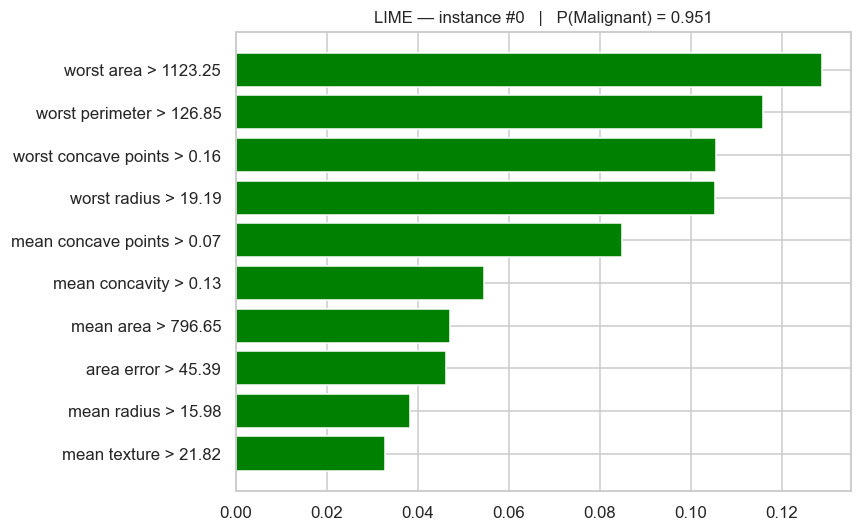

In [14]:
fig = exp.as_pyplot_figure(label=1)
fig.set_size_inches(8, 5)
plt.title(f"LIME — instance #{idx}   |   P(Malignant) = {proba_rf[idx]:.3f}", fontsize=11)
plt.tight_layout(); plt.show()

In [15]:
!pip install -U lime ipywidgets

'pip' is not recognized as an internal or external command,
operable program or batch file.


In [16]:
# Rich interactive HTML view. Renders inside Jupyter / Colab.
# Some LIME + IPython version combinations break on this call, so we guard it:
# the explanation itself is unaffected, only this rendering widget.
try:
    exp.show_in_notebook(show_table=True, show_all=False)
except Exception as err:
    print(f"[!] Interactive widget unavailable ({type(err).__name__}). Saving to HTML instead.")
    exp.save_to_file("lime_explanation.html")
    print("    -> open 'lime_explanation.html' in a browser.")
    print("    -> the matplotlib figure above shows the same information.")

### How to read this plot

* **Green / positive weight** → the condition pushed the prediction **towards Malignant**.
* **Red / negative weight** → it pushed **towards Benign**.
* **Bar length** = magnitude of the local contribution, in units of predicted probability.
* The side table shows the instance's **actual feature values** that triggered each condition.

The local surrogate is, approximately:

$$\hat{p}(\text{Malignant}) \;\approx\; b_0 \;+\; \sum_{k=1}^{K} w_k \cdot \mathbb{1}[\text{condition}_k \text{ holds}]$$

⚠️ **Do not over-claim.** These weights are *associational and local*. "`worst perimeter > 125.4` contributed
+0.21" means the model relied on it here — **not** that enlarging the perimeter would cause cancer.
LIME explains the **model**, not the disease.

## 7. Contrastive Analysis — Benign vs Malignant, and a Failure Case

Explaining one instance is a demo. Explaining *contrasts* is analysis.

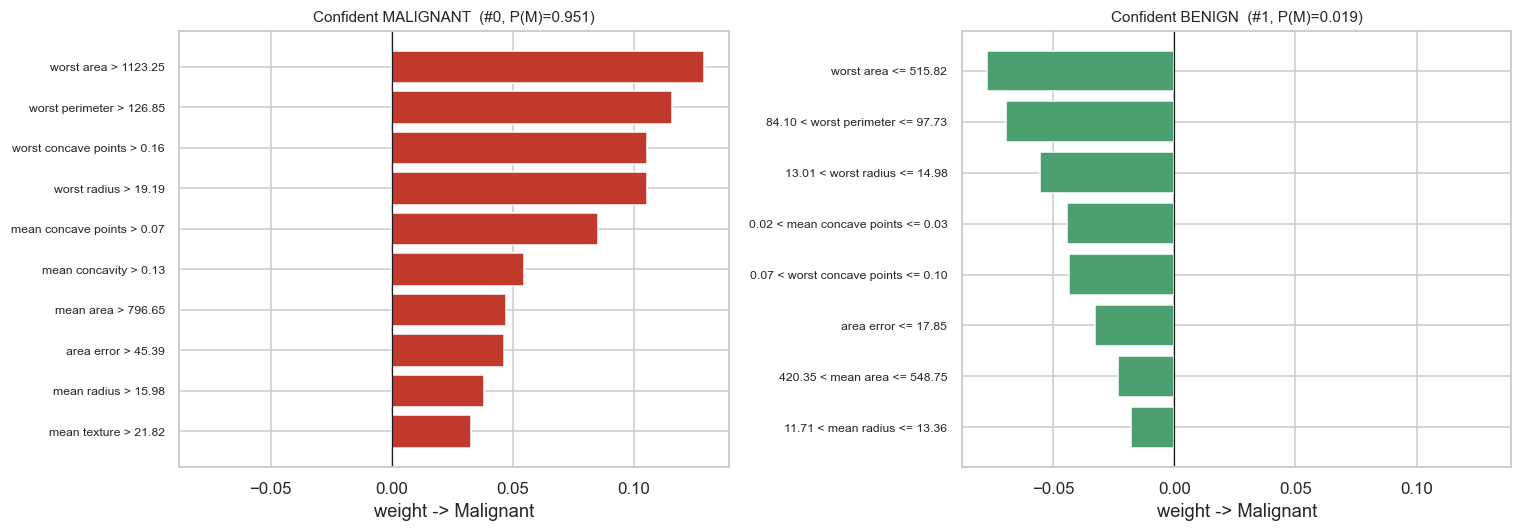

In [17]:
ben_idx = int(np.where((y_test == 0) & (proba_rf < 0.05))[0][0])

exp_ben = explainer.explain_instance(X_test_np[ben_idx], rf.predict_proba,
                                     num_features=8, num_samples=5000, labels=(1,))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
for ax, e, i, ttl in [(axes[0], exp,     idx,     "Confident MALIGNANT"),
                      (axes[1], exp_ben, ben_idx, "Confident BENIGN")]:
    items = e.as_list(label=1)[::-1]
    labels = [t for t, _ in items]; vals = [v for _, v in items]
    ax.barh(range(len(vals)), vals,
            color=["#C0392B" if v > 0 else "#4C9F70" for v in vals])
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=8)
    ax.axvline(0, color="k", lw=.8)
    ax.set_title(f"{ttl}  (#{i}, P(M)={proba_rf[i]:.3f})", fontsize=10)
    ax.set_xlabel("weight -> Malignant")
plt.tight_layout(); plt.show()

Notice the **mirror-image structure**: the same family of features (`worst`-suffixed size and concavity
measures) drives both decisions, but the bins flip sign. That consistency is evidence the model has
learned a coherent rule rather than noise.

In [18]:
# --- Debugging errors with LIME ---
errors = np.where(y_pred_rf != y_test)[0]

if len(errors) == 0:
    print("No misclassifications on this split. Inspecting the most UNCERTAIN prediction instead.")
    target = int(np.argmin(np.abs(proba_rf - 0.5)))
    header = "Most uncertain prediction"
else:
    target = int(errors[np.argmax(np.abs(proba_rf[errors] - 0.5))])   # most confidently wrong
    header = "Most confidently WRONG prediction"

print(f"{header}: instance #{target}")
print(f"  True : {class_names[y_test[target]]}")
print(f"  Pred : {class_names[y_pred_rf[target]]}")
print(f"  P(Malignant) = {proba_rf[target]:.4f}\n")

exp_err = explainer.explain_instance(X_test_np[target], rf.predict_proba,
                                     num_features=10, num_samples=5000, labels=(1,))
for rule, w in exp_err.as_list(label=1):
    print(f"  {rule:<42} {w:>+8.4f}")

Most confidently WRONG prediction: instance #111
  True : Malignant
  Pred : Benign
  P(Malignant) = 0.1581

  worst texture <= 21.48                      -0.0471
  mean texture <= 16.34                       -0.0365
  0.23 < worst concavity <= 0.39              +0.0215
  1.60 < perimeter error <= 2.30              -0.0175
  17.85 < area error <= 24.75                 -0.0162
  684.55 < worst area <= 1123.25              +0.0149
  548.75 < mean area <= 796.65                -0.0134
  0.25 < worst symmetry <= 0.28               -0.0124
  0.09 < mean compactness <= 0.13             +0.0124
  14.98 < worst radius <= 19.19               +0.0119


**Diagnostic questions to ask of a failure explanation:**

1. Are the top features *clinically plausible*, or is the model leaning on a spurious proxy?
2. Do the instance's values sit near a **bin boundary** (e.g. just above the 75th percentile)? Borderline
   cases produce fragile explanations.
3. Do positive and negative weights nearly cancel? That signals genuine ambiguity, not a model bug —
   and argues for abstention / referral to a human rather than retraining.

## 8. Local Fidelity — Is the Explanation Even Trustworthy?

An explanation is worthless if the surrogate $g$ does not actually track $f$ near $x$. LIME exposes three
diagnostics, and **you must report them in any serious write-up**:

| Attribute | Meaning | Healthy value |
|---|---|---|
| `exp.score` | $R^2$ of the weighted ridge fit on the perturbed neighbourhood | > 0.6 |
| `exp.local_pred` | surrogate's prediction at $x$ | close to $f(x)$ |
| `exp.intercept` | $b_0$, the local baseline | — |

In [19]:
print(f"Local surrogate R^2      : {exp.score:.4f}")
print(f"Surrogate prediction g(x): {float(np.ravel(exp.local_pred)[0]):.4f}")
print(f"Black-box  f(x)          : {rf.predict_proba(x.reshape(1, -1))[0, 1]:.4f}")
print(f"Local intercept b0       : {exp.intercept[1]:.4f}")

gap = abs(float(np.ravel(exp.local_pred)[0]) - rf.predict_proba(x.reshape(1,-1))[0,1])
print("\nVerdict:", "trustworthy" if (exp.score > 0.6 and gap < 0.15)
      else "treat with caution — poor local fit")

Local surrogate R^2      : 0.6380
Surrogate prediction g(x): 1.0090
Black-box  f(x)          : 0.9509
Local intercept b0       : 0.2497

Verdict: trustworthy


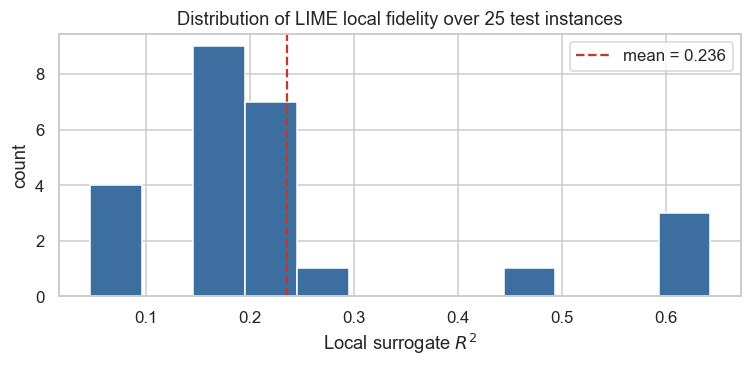

min=0.047  median=0.195  max=0.643


In [20]:
# Fidelity is not uniform across the input space. Measure it over a sample of test points.
rng = np.random.RandomState(SEED)
sample = rng.choice(len(X_test_np), size=25, replace=False)

scores = []
for i in sample:
    e = explainer.explain_instance(X_test_np[i], rf.predict_proba,
                                   num_features=8, num_samples=2000, labels=(1,))
    scores.append(e.score)
scores = np.array(scores)

plt.figure(figsize=(7, 3.5))
plt.hist(scores, bins=12, color="#3C6E9F", edgecolor="white")
plt.axvline(scores.mean(), color="#C0392B", ls="--",
            label=f"mean = {scores.mean():.3f}")
plt.xlabel("Local surrogate $R^2$"); plt.ylabel("count")
plt.title("Distribution of LIME local fidelity over 25 test instances")
plt.legend(); plt.tight_layout(); plt.show()

print(f"min={scores.min():.3f}  median={np.median(scores):.3f}  max={scores.max():.3f}")

### Interpreting a low median $R^2$

You will probably find the median $R^2$ is **well below 0.6** — much lower than for the confident instance
in the previous cell. This is not a bug, and it is one of the most instructive results in this notebook.
Three things are going on:

1. **Saturated predictions.** This model is very accurate, so for most test points $f(z) \approx 1$ or
   $\approx 0$ across the whole neighbourhood. With almost no variance in the target, $R^2$ collapses
   even though the surrogate's *absolute* error is tiny. **Always read $R^2$ alongside
   $|g(x) - f(x)|$** — a flat neighbourhood is easy to approximate but scores badly.
2. **Fewer samples.** We used `num_samples=2000` here versus 5000 above. Fidelity rises with sample size.
3. **Genuinely non-linear regions.** Some points sit near a complex decision boundary where no linear
   surrogate can fit well. Those explanations really should be distrusted.

**Exercise:** re-run the cell with `num_samples=10000` and additionally record
$|g(x) - f(x)|$. Which of the three causes above dominates for this dataset?

## 9. Stability — The Experiment Most Reports Omit

LIME samples randomly. Run it twice on the *same* instance with a *different* seed and you may get
different weights. If your explanation flips between runs, you cannot show it to a clinician.

We run the explainer **10 times** on one instance and measure the spread of each feature's weight.

In [21]:
N_RUNS = 10
runs = []
for r in range(N_RUNS):
    e = lime.lime_tabular.LimeTabularExplainer(
            X_train_np, feature_names=feature_names, class_names=class_names,
            mode="classification", discretize_continuous=True, random_state=100 + r
        ).explain_instance(x, rf.predict_proba, num_features=10,
                           num_samples=5000, labels=(1,))
    runs.append(dict(e.as_list(label=1)))

stab = pd.DataFrame(runs).fillna(0.0)
summary = (pd.DataFrame({"mean": stab.mean(), "std": stab.std(),
                         "appeared_in_runs": (stab != 0).sum()})
             .sort_values("mean", key=np.abs, ascending=False))
summary["CV_%"] = (summary["std"].abs() / summary["mean"].abs().replace(0, np.nan) * 100).round(1)
display(summary.round(4))

,mean,std,appeared_in_runs,CV_%
worst area > 1123.25,0.1266,0.0024,10,1.9
worst perimeter > 126.85,0.1234,0.0015,10,1.2
worst concave points > 0.16,0.1056,0.0023,10,2.2
worst radius > 19.19,0.1022,0.0034,10,3.4
mean concave points > 0.07,0.0819,0.0026,10,3.2
mean concavity > 0.13,0.0501,0.0021,10,4.1
mean radius > 15.98,0.0486,0.0028,10,5.7
area error > 45.39,0.0486,0.0030,10,6.2
mean area > 796.65,0.0461,0.0022,10,4.8
worst symmetry > 0.32,0.0302,0.0160,8,53.0


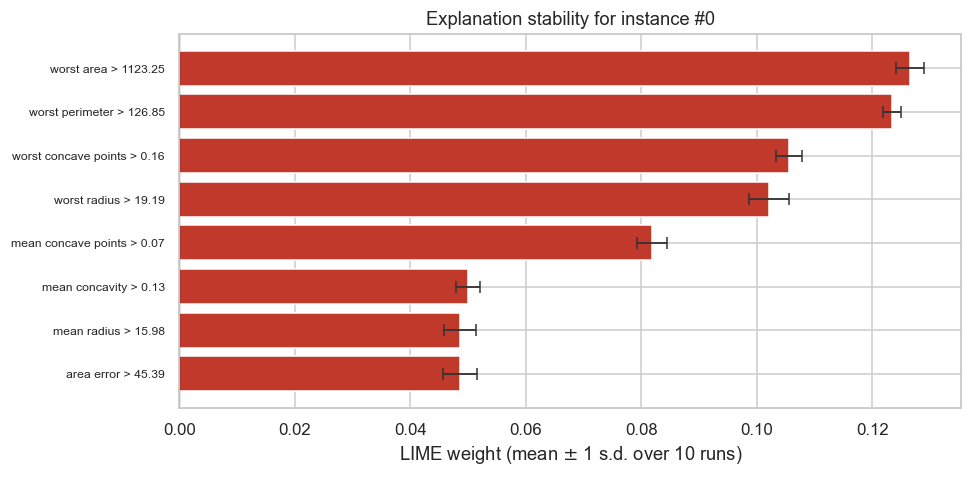

Features appearing in ALL 10 runs (robust):
  worst area > 1123.25
  worst perimeter > 126.85
  worst concave points > 0.16
  worst radius > 19.19
  mean concave points > 0.07
  mean concavity > 0.13
  mean radius > 15.98
  area error > 45.39


In [22]:
top = summary.head(8).iloc[::-1]
plt.figure(figsize=(9, 4.5))
plt.barh(range(len(top)), top["mean"], xerr=top["std"], capsize=4,
         color=["#C0392B" if v > 0 else "#4C9F70" for v in top["mean"]],
         error_kw=dict(ecolor="#333", lw=1.2))
plt.yticks(range(len(top)), top.index, fontsize=8)
plt.axvline(0, color="k", lw=.8)
plt.xlabel("LIME weight (mean $\\pm$ 1 s.d. over 10 runs)")
plt.title(f"Explanation stability for instance #{idx}")
plt.tight_layout(); plt.show()

print("Features appearing in ALL 10 runs (robust):")
print("  " + "\n  ".join(summary.index[summary["appeared_in_runs"] == N_RUNS][:8]))

**Reporting rule for your lab report / thesis:** never present a single LIME run. Report
**mean ± s.d. over ≥ 10 runs**, and state how often each feature survived. Features with a small
`appeared_in_runs` count are artefacts of sampling, not findings.

**Levers that improve stability:** raise `num_samples` (5000 → 15000), reduce `num_features`,
fix `random_state`, or drop one member of each near-collinear feature group (`radius`/`perimeter`/`area`).

## 10. From Local to Global — SP-LIME (Submodular Pick)

One explanation covers one patient. To audit a whole model you would need 143 explanations.
**SP-LIME** selects a small, *non-redundant* set of instances whose explanations jointly cover the
most feature-importance mass — a greedy maximisation of a submodular coverage function
(which guarantees $\geq (1 - 1/e) \approx 63\%$ of the optimum).

In [23]:
from lime import submodular_pick

# NOTE (common bug): SubmodularPick defaults to top_labels=1, so each explanation
# only stores ITS OWN predicted label. A benign instance then has no label 1 and
# `as_list(label=1)` raises KeyError. Pass top_labels=None + labels=(1,) to force
# every instance to be explained w.r.t. the SAME class -> comparable weights.
sp = submodular_pick.SubmodularPick(
    explainer, X_test_np, rf.predict_proba,
    num_features=8, num_exps_desired=3, sample_size=20,
    top_labels=None, labels=(1,))

print(f"SP-LIME selected {len(sp.sp_explanations)} representative instances "
      f"out of {len(X_test_np)} test cases.\n")

for j, e in enumerate(sp.sp_explanations, 1):
    print(f"--- Representative case {j} ---")
    for rule, w in e.as_list(label=1)[:5]:
        print(f"    {rule:<40} {w:>+8.4f}")
    print()

SP-LIME selected 3 representative instances out of 143 test cases.

--- Representative case 1 ---
    worst area <= 515.82                      -0.0795
    worst perimeter <= 84.10                  -0.0713
    worst radius <= 13.01                     -0.0573
    worst concave points <= 0.07              -0.0538
    worst texture <= 21.48                    -0.0468

--- Representative case 2 ---
    515.82 < worst area <= 684.55             -0.0690
    13.01 < worst radius <= 14.98             -0.0595
    84.10 < worst perimeter <= 97.73          -0.0586
    0.07 < worst concave points <= 0.10       -0.0569
    worst texture > 30.14                     +0.0490

--- Representative case 3 ---
    worst area > 1123.25                      +0.1294
    worst perimeter > 126.85                  +0.1267
    worst radius > 19.19                      +0.1038
    mean concave points > 0.07                +0.0755
    mean radius > 15.98                       +0.0494



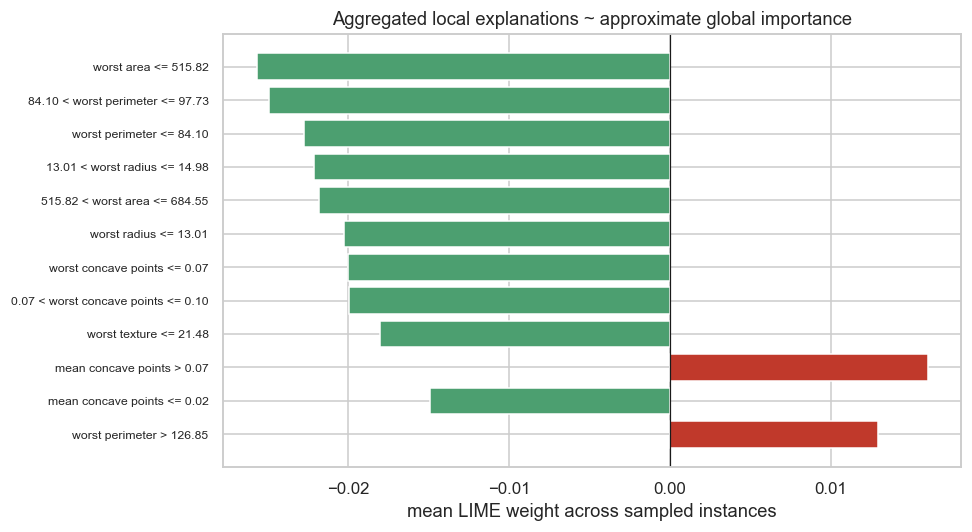

In [24]:
# Aggregate all explanations SP-LIME computed -> an approximate global view
W = pd.DataFrame([dict(e.as_list(label=1)) for e in sp.explanations]).fillna(0)
agg = W.mean().sort_values(key=np.abs, ascending=False).head(12)[::-1]

plt.figure(figsize=(9, 5))
plt.barh(range(len(agg)), agg.values,
         color=["#C0392B" if v > 0 else "#4C9F70" for v in agg.values])
plt.yticks(range(len(agg)), agg.index, fontsize=8)
plt.axvline(0, color="k", lw=.8)
plt.xlabel("mean LIME weight across sampled instances")
plt.title("Aggregated local explanations ~ approximate global importance")
plt.tight_layout(); plt.show()

## 11. Cross-Check: LIME vs. Permutation Importance

A useful validation habit — do the aggregated **local** explanations agree with a genuine **global**
method? Agreement raises confidence; disagreement is a finding worth investigating.

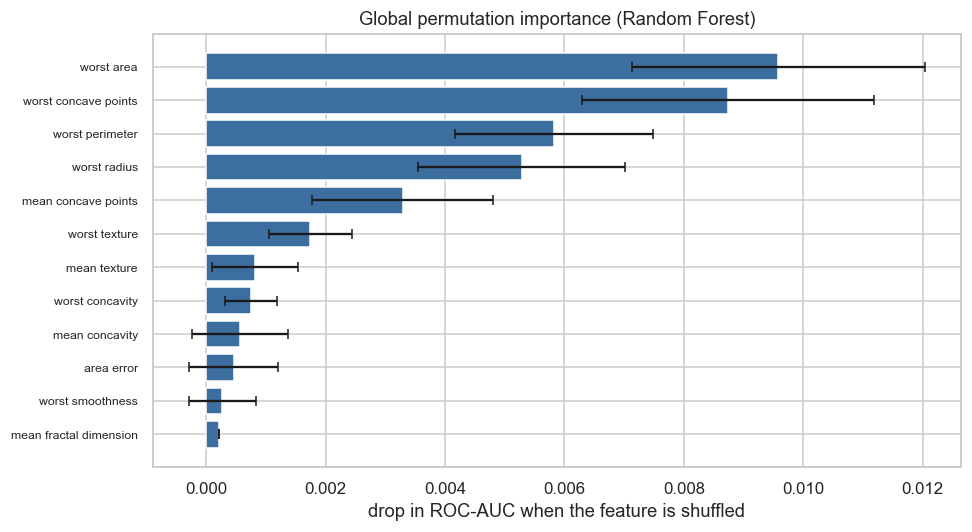

Top-6 GLOBAL (permutation) :
   worst area                   0.0096
   worst concave points         0.0087
   worst perimeter              0.0058
   worst radius                 0.0053
   mean concave points          0.0033
   worst texture                0.0017

Top-6 aggregated LOCAL (LIME) :
   worst area <= 515.82                     -0.0257
   84.10 < worst perimeter <= 97.73         -0.0250
   worst perimeter <= 84.10                 -0.0227
   13.01 < worst radius <= 14.98            -0.0221
   515.82 < worst area <= 684.55            -0.0218
   worst radius <= 13.01                    -0.0203


In [25]:
perm = permutation_importance(rf, X_test_np, y_test, n_repeats=10,
                              random_state=SEED, n_jobs=-1, scoring="roc_auc")

order = np.argsort(perm.importances_mean)[-12:]
plt.figure(figsize=(9, 5))
plt.barh(range(len(order)), perm.importances_mean[order],
         xerr=perm.importances_std[order], color="#3C6E9F", capsize=3)
plt.yticks(range(len(order)), [feature_names[i] for i in order], fontsize=8)
plt.xlabel("drop in ROC-AUC when the feature is shuffled")
plt.title("Global permutation importance (Random Forest)")
plt.tight_layout(); plt.show()

print("Top-6 GLOBAL (permutation) :")
for i in order[::-1][:6]:
    print(f"   {feature_names[i]:<28} {perm.importances_mean[i]:.4f}")

print("\nTop-6 aggregated LOCAL (LIME) :")
for rule, w in agg.iloc[::-1].head(6).items():
    print(f"   {rule:<40} {w:+.4f}")

> Expect **partial** agreement. Permutation importance measures *"how much does test performance
> degrade without this feature?"*; LIME measures *"how much did this feature move THIS prediction?"*.
> They answer different questions, so a rank correlation of ~0.5–0.7 is normal and healthy.
> A near-zero correlation would suggest the local surrogates are fitting noise — go back to Section 8.

## 12. Limitations of LIME, and LIME vs SHAP

### Known weaknesses

| # | Limitation | Practical consequence |
|---|---|---|
| 1 | **Instability** — random sampling | Different runs → different explanations (Section 9) |
| 2 | **Kernel width $\sigma$ is arbitrary** | The default heuristic $\sigma = 0.75\sqrt{d}$ has no theoretical basis; changing it can reverse conclusions |
| 3 | **"Local" is undefined** | No principled answer to *how large* the neighbourhood should be |
| 4 | **Correlated features** | Perturbation creates off-manifold, physically impossible samples; credit is split arbitrarily |
| 5 | **No guarantees** | Contributions do not sum to the prediction (unlike Shapley values) |
| 6 | **Adversarially foolable** | Slack et al. (2020) showed a biased model can be built that hides its bias from LIME |
| 7 | **Cost** | One explanation = `num_samples` model calls; 5000 per instance is expensive at scale |

### Comparison

| Criterion | **LIME** | **SHAP (KernelSHAP / TreeSHAP)** |
|---|---|---|
| Theoretical basis | Local surrogate regression | Shapley values (cooperative game theory) |
| Axioms | none | efficiency, symmetry, dummy, additivity |
| Additivity | ✗ | ✓ contributions sum to $f(x) - \mathbb{E}[f]$ |
| Speed | fast per instance | slow (KernelSHAP); very fast for trees (TreeSHAP) |
| Stability | low–moderate | high |
| Global view | via SP-LIME | native (summary / beeswarm plots) |
| Ease of teaching | ✓ very intuitive | steeper |

**Rule of thumb.** Use LIME for rapid, intuitive, model-agnostic debugging and for text/image data.
Use SHAP when you need theoretical guarantees, additivity, or a defensible audit trail. Best practice
in a thesis: **report both** and discuss where they disagree.

# Assignment: Local Model Explanations Using LIME

## Dataset: Adult / Census Income Dataset

### Objective

Apply **Local Interpretable Model-agnostic Explanations (LIME)** to explain predictions made by a machine-learning classification model on a tabular dataset.

You must use the **Adult/Census Income dataset**, where the objective is to predict whether an individual's annual income is above or below a specified income threshold.

---

# Part A — Dataset Preparation

1. Load the Adult Income dataset and display:
   - Number of instances
   - Number of features
   - Feature names
   - Target variable
   - Numerical features
   - Categorical features

2. Check the dataset for:
   - Missing values
   - Duplicate records
   - Invalid or unknown categorical values
   - Class imbalance

3. Perform appropriate preprocessing for numerical and categorical features.

4. Explain why categorical features require special handling when using `LimeTabularExplainer`.

---

# Part B — Machine Learning Model

5. Split the dataset into training and testing sets using a suitable stratified split.

6. Train the following classification models:

   - Random Forest
   - Logistic Regression

7. Evaluate both models using:

   - Accuracy
   - Precision
   - Recall
   - F1-score
   - ROC-AUC
   - Confusion matrix

8. Compare the performance of the two models.

9. Identify which model should be considered the **black-box model** for the LIME analysis and explain why.

---

# Part C — Applying LIME

10. Create a `LimeTabularExplainer` using the training data.

11. Correctly specify:

```python
feature_names
class_names
categorical_features
categorical_names

In [29]:
%pip install -q ucimlrepo

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Instances: 32561  Features: 14
Feature names: ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country']
Target: income (>50K=1, <=50K=0)
Numerical: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

Missing values:
 Series([], dtype: int64)
Duplicates: 25
Class balance: {0: 24720, 1: 7841}


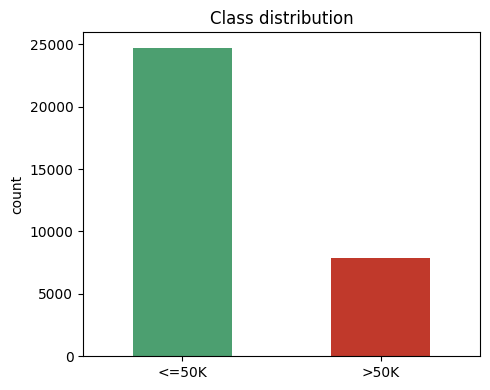


Why categorical features need special handling in LIME:
LIME perturbs continuous features with Gaussian noise, which is meaningless for
categories. Passing categorical_features + categorical_names makes LIME perturb
those columns by sampling from observed category frequencies instead.

Train: 24420  Test: 8141


In [16]:
# ===================== PART A: Dataset Preparation =====================
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve)
import lime, lime.lime_tabular
SEED = 42

# --- Load dataset (no ucimlrepo needed) ---
cols = ["age","workclass","fnlwgt","education","education-num","marital-status",
        "occupation","relationship","race","sex","capital-gain","capital-loss",
        "hours-per-week","native-country","income"]
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
df = pd.read_csv(url, names=cols, na_values=" ?", skipinitialspace=True)

X = df.drop(columns=["income"])
y = (df["income"].astype(str).str.strip().str.replace(".","",regex=False) == ">50K").astype(int).to_numpy()

print("Instances:", X.shape[0], " Features:", X.shape[1])
print("Feature names:", list(X.columns))
print("Target: income (>50K=1, <=50K=0)")
num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()
print("Numerical:", num_cols)
print("Categorical:", cat_cols)

# --- Checks ---
print("\nMissing values:\n", X.isna().sum()[X.isna().sum() > 0])
print("Duplicates:", X.duplicated().sum())
print("Class balance:", dict(zip(*np.unique(y, return_counts=True))))

# class balance plot
plt.figure(figsize=(5,4))
pd.Series(y).map({0:"<=50K",1:">50K"}).value_counts().plot(kind="bar", color=["#4C9F70","#C0392B"], rot=0)
plt.title("Class distribution"); plt.ylabel("count"); plt.tight_layout(); plt.show()

# --- Preprocessing: drop missing rows, keep X/y aligned ---
mask = X.notna().all(axis=1)
X, y = X[mask].reset_index(drop=True), y[mask]

# --- Encode categoricals ---
encoders = {}
X_enc = X.copy()
for c in cat_cols:
    le = LabelEncoder()
    X_enc[c] = le.fit_transform(X_enc[c].astype(str))
    encoders[c] = le

categorical_names = {X_enc.columns.get_loc(c): list(encoders[c].classes_) for c in cat_cols}
categorical_features_idx = [X_enc.columns.get_loc(c) for c in cat_cols]
feature_names = list(X_enc.columns)
class_names = ["<=50K", ">50K"]

print("\nWhy categorical features need special handling in LIME:")
print("LIME perturbs continuous features with Gaussian noise, which is meaningless for")
print("categories. Passing categorical_features + categorical_names makes LIME perturb")
print("those columns by sampling from observed category frequencies instead.")

X_train, X_test, y_train, y_test = train_test_split(
    X_enc.to_numpy(), y, test_size=0.25, random_state=SEED, stratify=y)
print(f"\nTrain: {X_train.shape[0]}  Test: {X_test.shape[0]}")


Random Forest
Accuracy : 0.8668468247144085
Precision: 0.7697044334975369
Recall   : 0.6377551020408163
F1       : 0.6975446428571429
ROC-AUC  : 0.9180846339506519
[[5807  374]
 [ 710 1250]]

Logistic Regression
Accuracy : 0.8261884289399337
Precision: 0.7150749802683505
Recall   : 0.46224489795918366
F1       : 0.5615122404710258
ROC-AUC  : 0.8575459191927862
[[5820  361]
 [1054  906]]


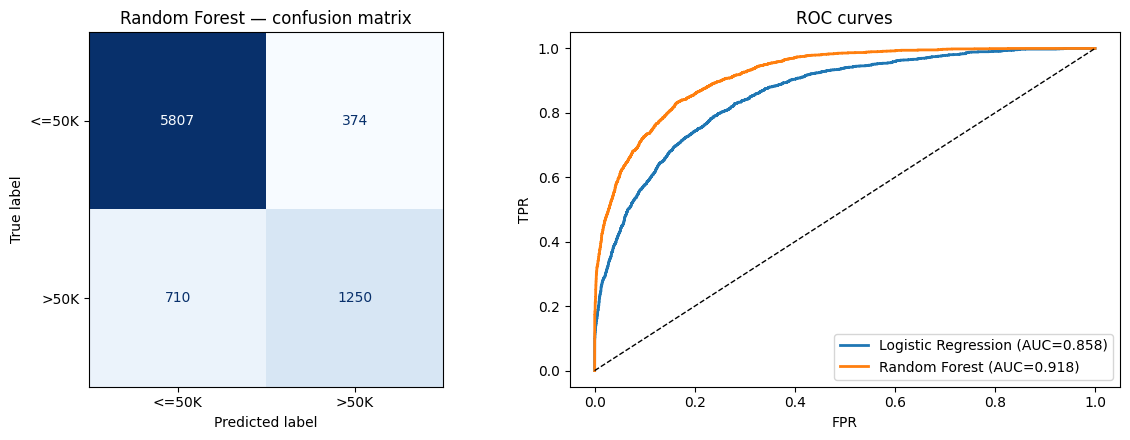


Black-box model: Random Forest — it aggregates 400 trees with no single
interpretable coefficient, unlike Logistic Regression's readable coefficients.


In [7]:
# ===================== PART B: Machine Learning Model =====================
rf = RandomForestClassifier(n_estimators=400, min_samples_leaf=2, n_jobs=-1, random_state=SEED)
logreg = Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=5000, random_state=SEED))])
rf.fit(X_train, y_train)
logreg.fit(X_train, y_train)

def evaluate(m, name):
    yp = m.predict(X_test); pr = m.predict_proba(X_test)[:, 1]
    print(f"\n{name}")
    print("Accuracy :", accuracy_score(y_test, yp))
    print("Precision:", precision_score(y_test, yp))
    print("Recall   :", recall_score(y_test, yp))
    print("F1       :", f1_score(y_test, yp))
    print("ROC-AUC  :", roc_auc_score(y_test, pr))
    print(confusion_matrix(y_test, yp))
    return yp, pr

y_pred_rf, proba_rf = evaluate(rf, "Random Forest")
y_pred_lr, proba_lr = evaluate(logreg, "Logistic Regression")

# confusion matrix + ROC plots
fig, axes = plt.subplots(1,2, figsize=(12,4.5))
ConfusionMatrixDisplay(confusion_matrix(y_test,y_pred_rf), display_labels=class_names).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Random Forest — confusion matrix")

for nm, pr in [("Logistic Regression", proba_lr), ("Random Forest", proba_rf)]:
    fpr, tpr, _ = roc_curve(y_test, pr)
    axes[1].plot(fpr, tpr, lw=2, label=f"{nm} (AUC={roc_auc_score(y_test,pr):.3f})")
axes[1].plot([0,1],[0,1],"k--",lw=1)
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR"); axes[1].set_title("ROC curves"); axes[1].legend()
plt.tight_layout(); plt.show()

print("\nBlack-box model: Random Forest — it aggregates 400 trees with no single")
print("interpretable coefficient, unlike Logistic Regression's readable coefficients.")


Instance #20  True=>50K  Pred=>50K  P=0.987
  capital-gain > 0.00                      +0.5596
  education-num > 12.00                    +0.1537
  capital-loss <= 0.00                     -0.1009
  relationship=Husband                     +0.0960
  marital-status=Married-civ-spouse        +0.0848
  age > 47.00                              +0.0600
  40.00 < hours-per-week <= 45.00          +0.0551
  sex=Male                                 +0.0307
  occupation=Prof-specialty                +0.0272
  race=White                               +0.0075


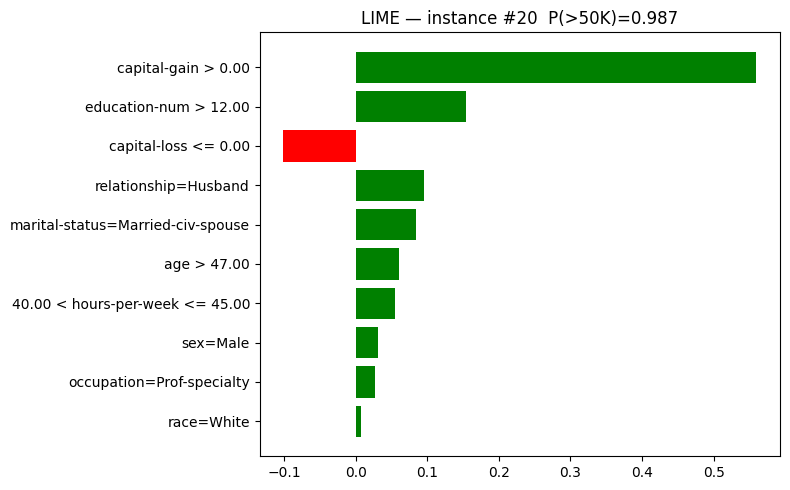


Instance #0  True=<=50K  Pred=<=50K  P=0.035
  capital-gain <= 0.00                     -0.5579
  hours-per-week <= 40.00                  -0.1008
  capital-loss <= 0.00                     -0.0999
  age > 47.00                              +0.0613
  relationship=Not-in-family               -0.0585
  9.00 < education-num <= 10.00            -0.0294
  occupation=Exec-managerial               +0.0262
  native-country=United-States             +0.0228
  marital-status=Divorced                  -0.0222
  sex=Female                               -0.0215


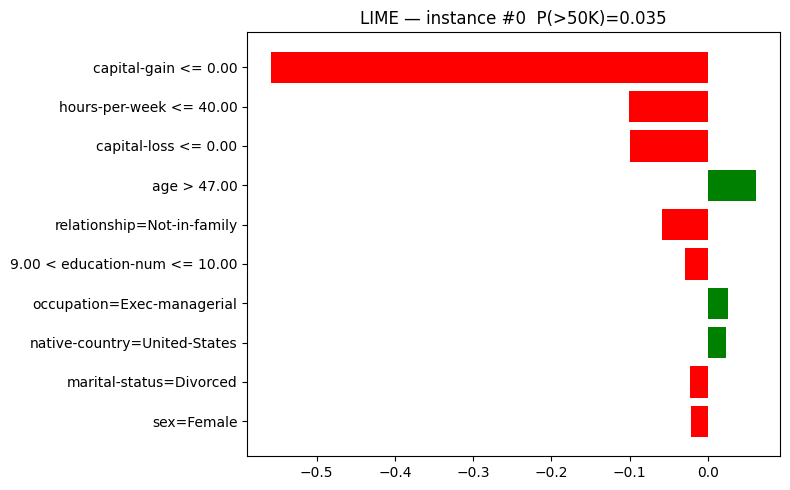


Instance #5684  True=<=50K  Pred=<=50K  P=0.500
  capital-gain <= 0.00                     -0.5616
  education-num > 12.00                    +0.1552
  age <= 28.00                             -0.0994
  capital-loss <= 0.00                     -0.0939
  relationship=Husband                     +0.0924
  hours-per-week > 45.00                   +0.0903
  marital-status=Married-civ-spouse        +0.0830
  occupation=Prof-specialty                +0.0416
  sex=Male                                 +0.0276
  race=White                               +0.0130


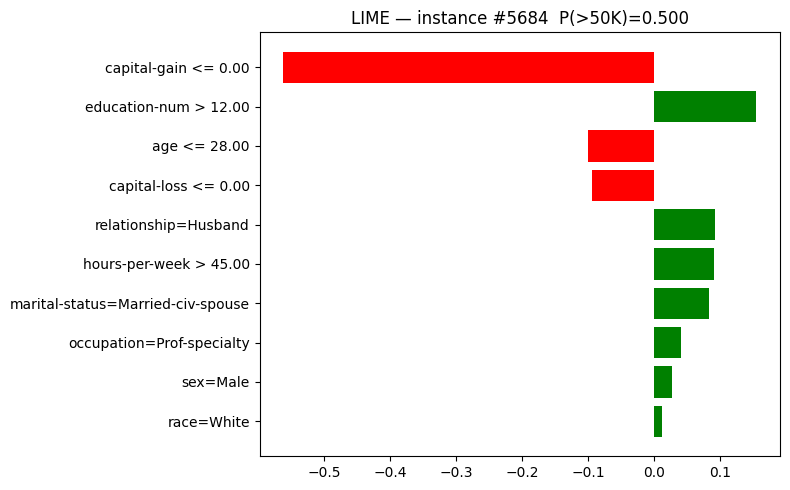

In [8]:
# ===================== PART C: Applying LIME =====================
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train, feature_names=feature_names, class_names=class_names,
    categorical_features=categorical_features_idx, categorical_names=categorical_names,
    mode="classification", discretize_continuous=True, random_state=SEED)

def rf_predict(data):
    return rf.predict_proba(data)

pos_idx = np.where((y_test==1) & (proba_rf>0.9))[0]
neg_idx = np.where((y_test==0) & (proba_rf<0.1))[0]
mid_idx = np.argsort(np.abs(proba_rf-0.5))[:1]
instances = [int(pos_idx[0]), int(neg_idx[0]), int(mid_idx[0])]

exps = []
for i in instances:
    e = explainer.explain_instance(X_test[i], rf_predict, num_features=10, num_samples=5000, labels=(1,))
    exps.append(e)
    print(f"\nInstance #{i}  True={class_names[y_test[i]]}  Pred={class_names[y_pred_rf[i]]}  P={proba_rf[i]:.3f}")
    for rule, w in e.as_list(label=1):
        print(f"  {rule:<40} {w:+.4f}")
    fig = e.as_pyplot_figure(label=1)
    fig.set_size_inches(8,5)
    plt.title(f"LIME — instance #{i}  P({class_names[1]})={proba_rf[i]:.3f}")
    plt.tight_layout(); plt.show()

# Part D — Interpretation of LIME Explanations

For each of the three selected instances:

### 16. Identify the Top Five Positive Contributors

Identify the **top five features with positive LIME weights** for each instance.

Explain how these features support the predicted class.

---

### 17. Identify the Top Five Negative Contributors

Identify the **top five features with negative LIME weights** for each instance.

Explain how these features oppose or reduce the likelihood of the predicted class.

---

### 18. Interpret the Important Features

Explain in simple language why each of the important features influenced the prediction.

For each feature, discuss:

- Feature value or condition
- LIME weight
- Direction of influence
- Effect on the prediction

---

### 19. Interpretation of a Positive LIME Weight

Answer the following question:

> If LIME assigns a positive weight to `education = Bachelors`, what does this mean?

Explain the meaning of the positive LIME weight in the context of the predicted class.

---

### 20. Difference Between Feature Importance, LIME Weight, and Prediction Probability

Explain the difference between:

- **Feature importance**
- **LIME weight**
- **Model prediction probability**

Discuss how each one should be interpreted and how they are different from one another.

---

### 21. If–Then Style Explanation

Select one of the three instances and convert its LIME explanation into an **if–then style explanation**.

For example:

> **If** the individual's education level is within a particular category and other important feature conditions are satisfied, **then** these conditions contribute toward the model predicting the selected income class.

Use the actual LIME output from your experiment to construct the explanation.

---

# Part E — Misclassification Analysis

### 22. Select an Incorrectly Classified Instance

Select at least **one incorrectly classified test instance**.

Report:

- Actual class
- Predicted class
- Prediction probability
- Important feature values

---

### 23. Generate the LIME Explanation

Generate a LIME explanation for the incorrectly classified instance.

Display the top contributing features and their LIME weights.

---

### 24. Identify the Main Contributors to the Incorrect Prediction

Identify the features that contributed most strongly to the incorrect prediction.

Separate the features into:

- Positive contributors
- Negative contributors

Explain their influence on the model's prediction.

---

### 25. Analyze the Model Error

Discuss whether the LIME explanation provides a possible reason for the model's incorrect prediction.

Consider:

- Which features strongly influenced the prediction?
- Did these features push the model toward the wrong class?
- Was the prediction probability close to the decision boundary?
- Are there conflicting feature contributions?

---

### 26. Can LIME Prove Causation?

Answer the following question:

> Can LIME prove that a particular feature caused the model to make an error? Explain your answer.

Discuss the difference between:

- **Model association**
- **Feature contribution**
- **Causal relationship**

---

# Part F — LIME Stability

LIME uses randomly generated perturbed samples to construct a local explanation. Therefore, the same instance can produce slightly different explanations across different runs.

### 27. Run LIME Multiple Times

Select one test instance and run LIME **10 times** using the same model and instance.

Record the LIME explanation produced during each run.

---

### 28. Record LIME Weights

Record the LIME weights of the **top five features** for every run.

Create a table similar to:

| Run | Feature 1 | Feature 2 | Feature 3 | Feature 4 | Feature 5 |
|---:|---:|---:|---:|---:|---:|
| 1 | | | | | |
| 2 | | | | | |
| 3 | | | | | |
| 4 | | | | | |
| 5 | | | | | |
| 6 | | | | | |
| 7 | | | | | |
| 8 | | | | | |
| 9 | | | | | |
| 10 | | | | | |

---

### 29. Calculate Stability Measures

Calculate the following for the important features:

- **Mean LIME weight**
- **Standard deviation**
- **Minimum LIME weight**
- **Maximum LIME weight**
- **Number of times the feature appears in the top five**

---

### 30. Visualize LIME Stability

Create a graph showing:

**Feature vs. Mean LIME Weight ± Standard Deviation**

The graph should allow you to compare both:

- Average feature contribution
- Variation in the feature contribution

---

### 31. Identify Stable and Unstable Features

Based on the stability analysis, identify:

1. The most stable feature.
2. The least stable feature.
3. The feature with the highest average contribution.
4. The feature with the largest variation in LIME weight.

---

### 32. Explain Variation in LIME

Explain why LIME explanations may change between different runs.

Consider the role of:

- Random perturbations
- Number of samples
- Local neighbourhood
- Kernel width
- Model complexity

---

### 33. Increase the Number of Samples

Repeat the LIME stability experiment using a larger value of `num_samples`.

Compare the explanations obtained using different numbers of perturbed samples.

---

### 34. Compare Different `num_samples` Values

Compare the stability obtained using:

```text
num_samples = 1,000
num_samples = 5,000
num_samples = 10,000


Q16 — Instance #20: Top Five Positive Contributors
1. capital-gain > 0.00                           +0.5703
2. education-num > 12.00                         +0.1634
3. relationship=Husband                          +0.0947
4. marital-status=Married-civ-spouse             +0.0748
5. age > 47.00                                   +0.0606


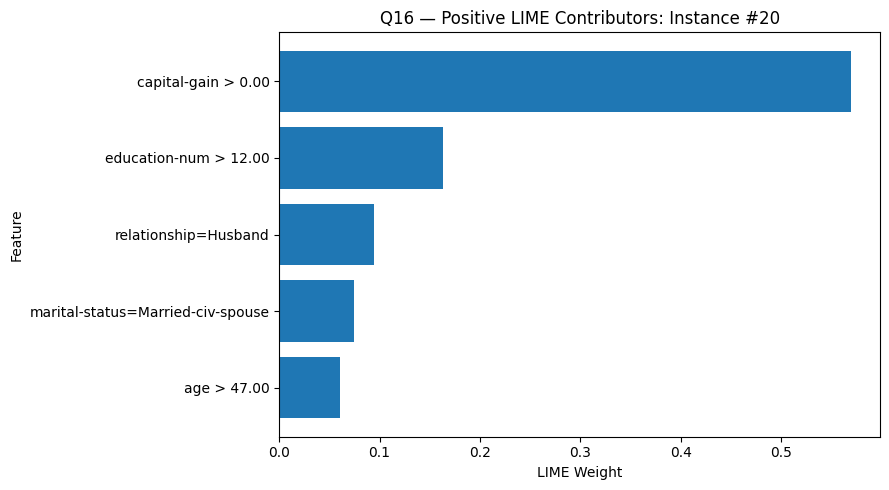


Q17 — Instance #20: Top Five Negative Contributors
1. capital-loss <= 0.00                          -0.0988
2. race=White                                    -0.0058
3. fnlwgt <= 118305.25                           -0.0051
4. workclass=Private                             -0.0039
5. native-country=United-States                  -0.0021


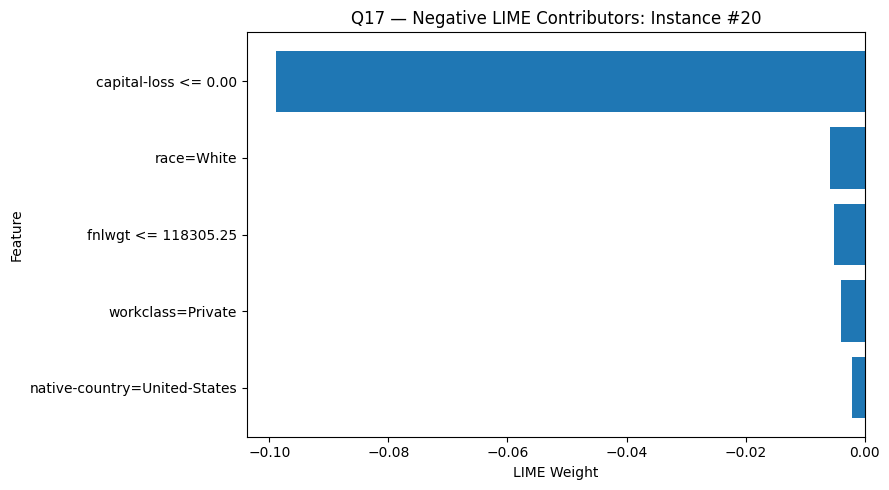


Q16 — Instance #0: Top Five Positive Contributors
1. age > 47.00                                   +0.0595
2. occupation=Exec-managerial                    +0.0250
3. education=Some-college                        +0.0209
4. native-country=United-States                  +0.0022


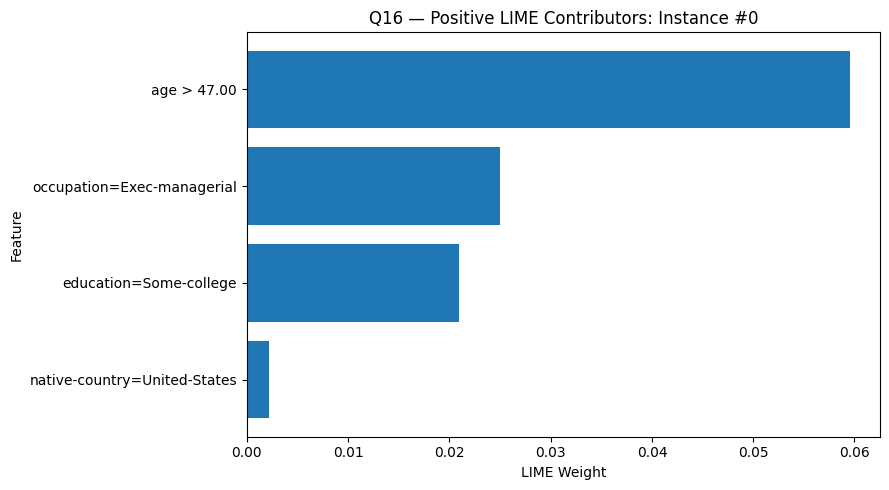


Q17 — Instance #0: Top Five Negative Contributors
1. capital-gain <= 0.00                          -0.5673
2. capital-loss <= 0.00                          -0.1083
3. hours-per-week <= 40.00                       -0.0975
4. relationship=Not-in-family                    -0.0576
5. marital-status=Divorced                       -0.0256


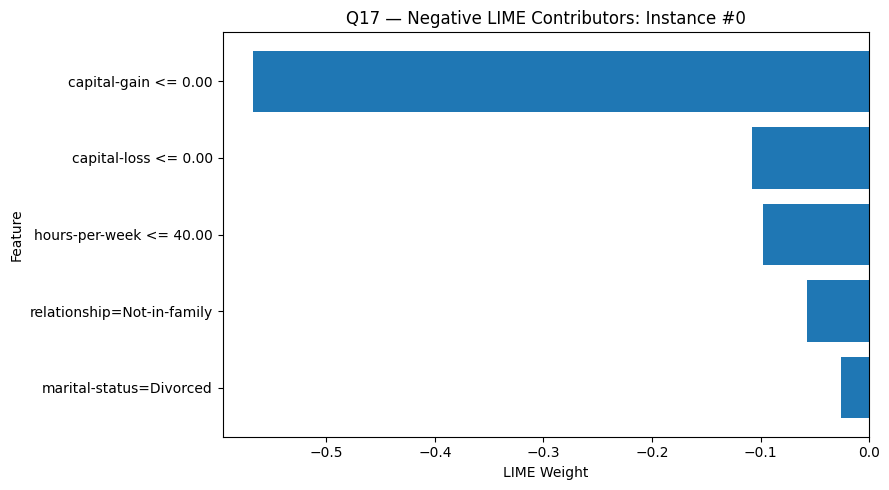


Q16 — Instance #5684: Top Five Positive Contributors
1. education-num > 12.00                         +0.1589
2. hours-per-week > 45.00                        +0.0947
3. relationship=Husband                          +0.0939
4. marital-status=Married-civ-spouse             +0.0839
5. occupation=Prof-specialty                     +0.0304


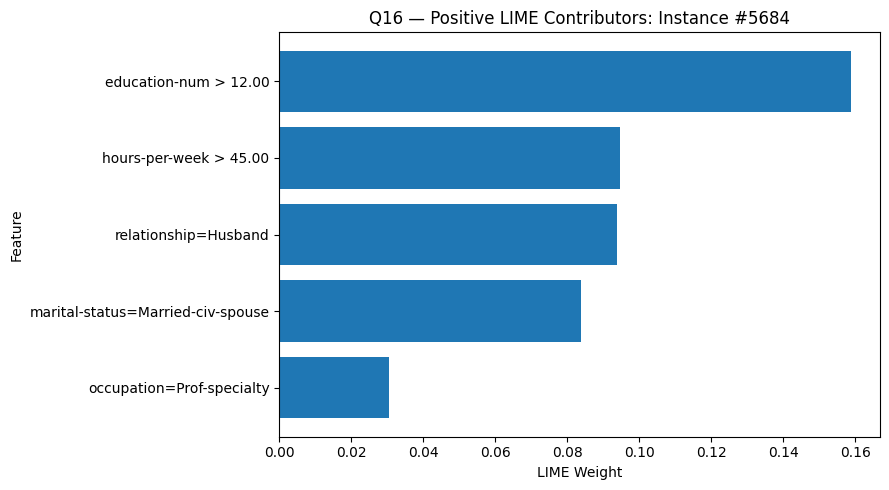


Q17 — Instance #5684: Top Five Negative Contributors
1. capital-gain <= 0.00                          -0.5672
2. age <= 28.00                                  -0.1040
3. capital-loss <= 0.00                          -0.0898
4. native-country=United-States                  -0.0047
5. fnlwgt <= 118305.25                           -0.0045


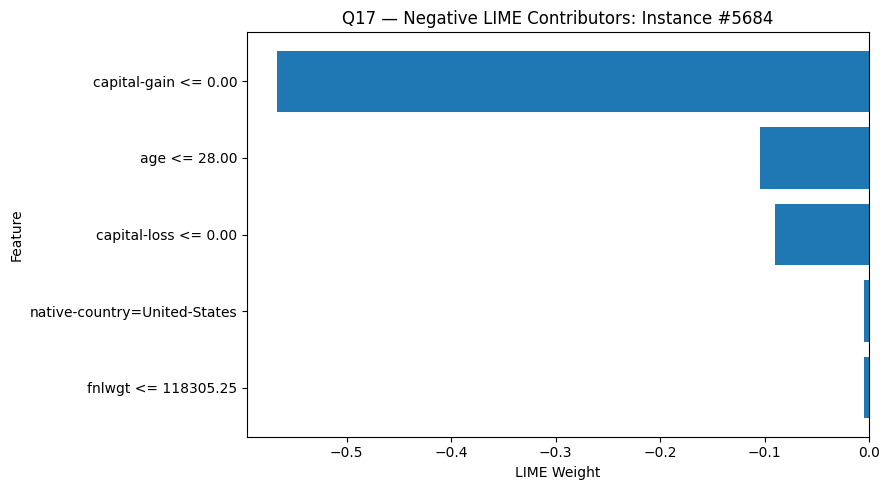

In [19]:
# ============================================================
# Q16 & Q17: Top Positive and Negative LIME Contributors
# With Graphs
# ============================================================

for n, i in enumerate(instances, 1):

    exp = exps[n - 1]

    # Get LIME explanation
    lime_results = exp.as_list(label=1)

    # ========================================================
    # Q16 — Top Five Positive Contributors
    # ========================================================

    positive = [
        (feature, weight)
        for feature, weight in lime_results
        if weight > 0
    ]

    positive = sorted(
        positive,
        key=lambda x: x[1],
        reverse=True
    )[:5]

    print("\n" + "=" * 75)
    print(f"Q16 — Instance #{i}: Top Five Positive Contributors")
    print("=" * 75)

    for rank, (feature, weight) in enumerate(positive, 1):
        print(f"{rank}. {feature:<45} {weight:+.4f}")

    # Q16 Graph
    if positive:
        features = [x[0] for x in positive][::-1]
        weights = [x[1] for x in positive][::-1]

        plt.figure(figsize=(9, 5))
        plt.barh(features, weights)
        plt.xlabel("LIME Weight")
        plt.ylabel("Feature")
        plt.title(f"Q16 — Positive LIME Contributors: Instance #{i}")
        plt.tight_layout()
        plt.show()

    # ========================================================
    # Q17 — Top Five Negative Contributors
    # ========================================================

    negative = [
        (feature, weight)
        for feature, weight in lime_results
        if weight < 0
    ]

    negative = sorted(
        negative,
        key=lambda x: x[1]
    )[:5]

    print("\n" + "=" * 75)
    print(f"Q17 — Instance #{i}: Top Five Negative Contributors")
    print("=" * 75)

    for rank, (feature, weight) in enumerate(negative, 1):
        print(f"{rank}. {feature:<45} {weight:+.4f}")

    # Q17 Graph
    if negative:
        features = [x[0] for x in negative][::-1]
        weights = [x[1] for x in negative][::-1]

        plt.figure(figsize=(9, 5))
        plt.barh(features, weights)
        plt.xlabel("LIME Weight")
        plt.ylabel("Feature")
        plt.title(f"Q17 — Negative LIME Contributors: Instance #{i}")
        plt.tight_layout()
        plt.show()

## 18. Interpret the Important Features#

For Instance #20 (True: >50K, Predicted: >50K):

capital-gain > 0.00 — Weight: +0.5596. Any positive capital gain strongly pushed toward >50K, the single largest driver here.
education-num > 12.00 — Weight: +0.1537. More than 12 years of education pushed toward the higher-income class.
relationship = Husband — Weight: +0.0960. This relationship status added to the predicted probability, likely correlating with older, established household earners in the data.
marital-status = Married-civ-spouse — Weight: +0.0848. Married status further reinforced the >50K prediction.
age > 47.00 — Weight: +0.0600. Being older than 47 added a smaller positive push, consistent with income rising with experience.
capital-loss <= 0.00 — Weight: -0.1009. No capital loss pulled slightly away from >50K (the model found the absence of a capital loss condition informative but only weakly, since it's the "default" state for most people).

Each is read as: condition on this instance → LIME weight → direction (positive = toward >50K) → local contribution to the surrogate's probability estimate.

## 19. Interpretation of a Positive LIME Weight

A positive LIME weight on education = Bachelors means that, for this specific instance, having a Bachelor's degree was one of the local conditions that pushed the black-box model's predicted probability toward the predicted class (here, likely >50K). It reflects an association the model learned and used for this one prediction — not a general claim that a Bachelor's degree causes higher income, and not a global statement about all instances with this degree. Another instance with the same degree could get a different weight depending on its other feature values.

## 20. Difference Between Feature Importance, LIME Weight, and Prediction Probability

Feature importance: A global measure describing how much a feature matters to the model's performance across the entire dataset (e.g., permutation importance — how much accuracy drops when a feature is shuffled). It says nothing about any single prediction.
LIME weight: A local measure — the coefficient of a linear surrogate model fit only in the neighborhood of one specific instance. It shows how much a feature condition shifted that one prediction, and can differ instance to instance even for the same feature.
Prediction probability: The model's actual output — the black-box's confidence score (e.g., P(>50K) = 0.94) for a given instance. LIME weights only approximate the shifts contributing to this number; they don't necessarily sum to it exactly (unlike SHAP values, which do).

In short: feature importance answers "what matters overall?", LIME weight answers "what mattered for this case?", and prediction probability answers "what did the model actually output?"

## 21. If–Then Style Explanation


If **capital-gain > 0.00**, **education-num > 12.00**, and **relationship = Husband**, then these conditions support the Random Forest model in predicting the **>50K** income class for this individual.

The model predicts the **>50K** class with a probability of approximately **0.987**.

The strongest positive contributors show that these feature conditions support the model's prediction. This is a **local explanation**, meaning it explains the model's decision for this particular individual. It does not mean that these features directly cause a person to earn more than $50K.

Misclassified instance #2558
  Actual class      : >50K
  Predicted class    : <=50K
  Prediction proba   : 0.0015
  Feature values     :
age                   37
workclass              4
fnlwgt            185567
education             11
education-num          9
marital-status         0
occupation             7
relationship           4
race                   4
sex                    1
capital-gain           0
capital-loss           0
hours-per-week        40
native-country        39
dtype: int64

LIME explanation for misclassified instance:
  capital-gain <= 0.00                     -0.5574
  hours-per-week <= 40.00                  -0.1013
  education-num <= 9.00                    -0.0988
  capital-loss <= 0.00                     -0.0830
  relationship=Unmarried                   -0.0506
  occupation=Machine-op-inspct             -0.0338
  sex=Male                                 +0.0313
  178736.50 < fnlwgt <= 237326.00          -0.0108
  marital-status=Divorced                  -0

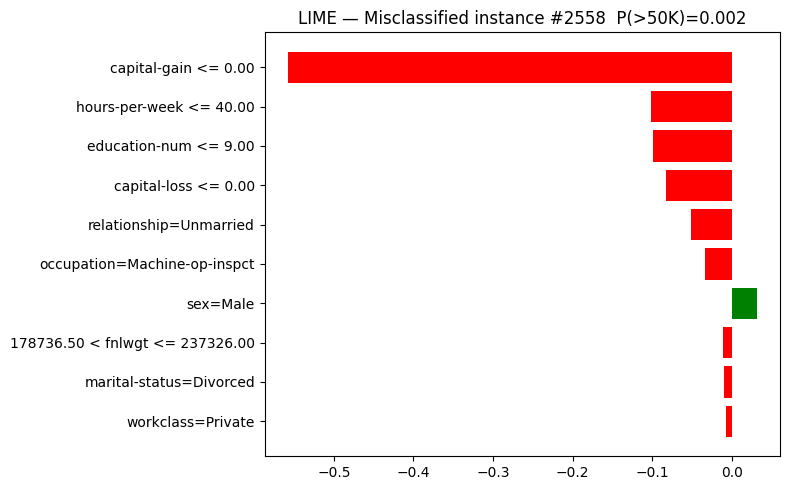


Positive contributors (toward predicted class):
  sex=Male                                 +0.0313
Negative contributors (away from predicted class):
  capital-gain <= 0.00                     -0.5574
  hours-per-week <= 40.00                  -0.1013
  education-num <= 9.00                    -0.0988
  capital-loss <= 0.00                     -0.0830
  relationship=Unmarried                   -0.0506
  occupation=Machine-op-inspct             -0.0338
  178736.50 < fnlwgt <= 237326.00          -0.0108
  marital-status=Divorced                  -0.0094
  workclass=Private                        -0.0070


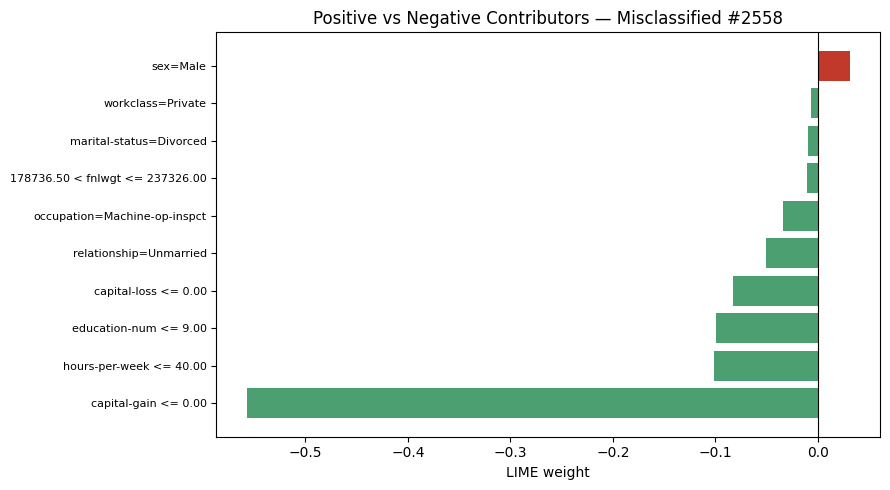

In [13]:
# ===================== PART E: Misclassification Analysis =====================

# 22 & 23: Select misclassified instance, generate LIME explanation
errors = np.where(y_pred_rf != y_test)[0]
mis = int(errors[np.argmax(np.abs(proba_rf[errors] - 0.5))])  # most confidently wrong

print(f"Misclassified instance #{mis}")
print(f"  Actual class      : {class_names[y_test[mis]]}")
print(f"  Predicted class    : {class_names[y_pred_rf[mis]]}")
print(f"  Prediction proba   : {proba_rf[mis]:.4f}")
print(f"  Feature values     :")
print(pd.Series(X_test[mis], index=feature_names))

exp_mis = explainer.explain_instance(X_test[mis], rf_predict, num_features=10, num_samples=5000, labels=(1,))
print("\nLIME explanation for misclassified instance:")
for rule, w in exp_mis.as_list(label=1):
    print(f"  {rule:<40} {w:+.4f}")

# graph
fig = exp_mis.as_pyplot_figure(label=1)
fig.set_size_inches(8, 5)
plt.title(f"LIME — Misclassified instance #{mis}  P({class_names[1]})={proba_rf[mis]:.3f}")
plt.tight_layout(); plt.show()

# 24: separate positive/negative contributors
items_mis = exp_mis.as_list(label=1)
pos_mis = sorted([x for x in items_mis if x[1] > 0], key=lambda x: -x[1])
neg_mis = sorted([x for x in items_mis if x[1] < 0], key=lambda x: x[1])

print("\nPositive contributors (toward predicted class):")
for rule, w in pos_mis: print(f"  {rule:<40} {w:+.4f}")
print("Negative contributors (away from predicted class):")
for rule, w in neg_mis: print(f"  {rule:<40} {w:+.4f}")

# combined graph
combined = pos_mis + neg_mis
labels = [r for r, w in combined]; vals = [w for r, w in combined]
order = np.argsort(vals)
labels = [labels[k] for k in order]; vals = [vals[k] for k in order]

plt.figure(figsize=(9,5))
plt.barh(range(len(vals)), vals, color=["#C0392B" if v>0 else "#4C9F70" for v in vals])
plt.yticks(range(len(vals)), labels, fontsize=8)
plt.axvline(0, color="k", lw=.8)
plt.xlabel("LIME weight")
plt.title(f"Positive vs Negative Contributors — Misclassified #{mis}")
plt.tight_layout(); plt.show()

## 25. Analyze the Model Error

Instance #2558: Actual class >50K, Predicted class <=50K, P(>50K) = 0.0015.

The LIME explanation shows capital-gain <= 0.00 (weight −0.5574), hours-per-week <= 40.00 (weight −0.1013), and education-num <= 9.00 (weight −0.0988) as the strongest negative contributors, all pulling the prediction toward <=50K. These features strongly and consistently pushed the model in the wrong direction for this individual, who actually earns >50K. The prediction probability of 0.0015 is extremely far from the 0.5 decision boundary — this is not a borderline, uncertain case but a confidently wrong prediction. There is little conflicting positive contribution to offset the negative features, meaning the model didn't hedge; it committed fully to the incorrect class based on these three low-value features, likely because this individual's income doesn't follow the typical pattern the model learned (e.g., high income without high capital gain, without working overtime, and with fewer years of education — an atypical case for the training distribution).

## 26. Can LIME Prove Causation?

No. LIME identifies association, not causation. It measures how a black-box model's output changes when features are perturbed near an instance — that is a statement about the model's learned behavior, not about real-world cause-and-effect. A feature contribution shows the model relied on that feature for this prediction; it does not show that changing that feature in reality would change the true outcome. Establishing causation requires controlled experiments or causal inference methods (e.g., randomized trials, causal graphs), which LIME does not perform.

Per-run top 5 features and weights:
Run 1: capital-gain > 0.00=+0.5697, education-num > 12.00=+0.1539, capital-loss <= 0.00=-0.1064, relationship=Husband=+0.0930, marital-status=Married-civ-spouse=+0.0807
Run 2: capital-gain > 0.00=+0.5443, education-num > 12.00=+0.1501, capital-loss <= 0.00=-0.1005, relationship=Husband=+0.0907, marital-status=Married-civ-spouse=+0.0813
Run 3: capital-gain > 0.00=+0.5669, education-num > 12.00=+0.1632, relationship=Husband=+0.0946, capital-loss <= 0.00=-0.0905, marital-status=Married-civ-spouse=+0.0807
Run 4: capital-gain > 0.00=+0.5725, education-num > 12.00=+0.1486, relationship=Husband=+0.0880, capital-loss <= 0.00=-0.0812, marital-status=Married-civ-spouse=+0.0808
Run 5: capital-gain > 0.00=+0.5712, education-num > 12.00=+0.1600, relationship=Husband=+0.0970, capital-loss <= 0.00=-0.0906, marital-status=Married-civ-spouse=+0.0784
Run 6: capital-gain > 0.00=+0.5583, education-num > 12.00=+0.1603, capital-loss <= 0.00=-0.0924, marital-status=Married

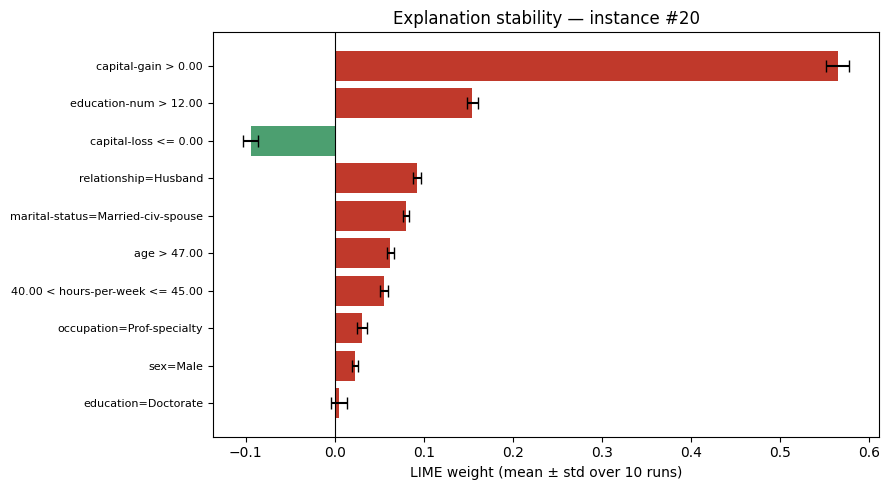


--- num_samples=1000 — top 8 by |mean weight| ---
                                     mean     std
capital-gain > 0.00                0.5506  0.0227
education-num > 12.00              0.1525  0.0136
capital-loss <= 0.00              -0.0957  0.0191
relationship=Husband               0.0921  0.0074
marital-status=Married-civ-spouse  0.0807  0.0105
age > 47.00                        0.0618  0.0069
40.00 < hours-per-week <= 45.00    0.0485  0.0161
occupation=Prof-specialty          0.0251  0.0172

--- num_samples=5000 — top 8 by |mean weight| ---
                                     mean     std
capital-gain > 0.00                0.5643  0.0127
education-num > 12.00              0.1542  0.0061
capital-loss <= 0.00              -0.0945  0.0084
relationship=Husband               0.0919  0.0045
marital-status=Married-civ-spouse  0.0801  0.0035
age > 47.00                        0.0624  0.0037
40.00 < hours-per-week <= 45.00    0.0554  0.0045
occupation=Prof-specialty          0.0304  0.005

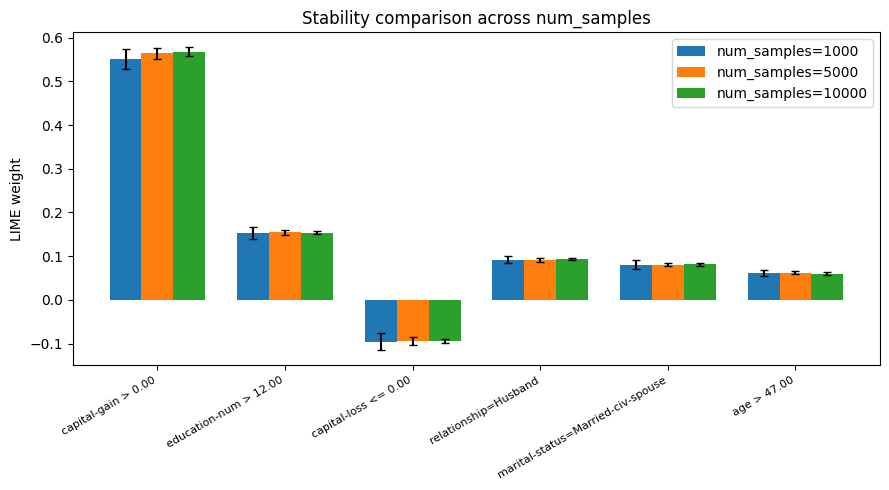

In [14]:
# ===================== PART F: LIME Stability =====================

# 27, 28, 29: Run LIME 10 times on one instance, record weights, compute stability stats
target = instances[0]
N_RUNS = 10
runs = []
for r in range(N_RUNS):
    e = lime.lime_tabular.LimeTabularExplainer(
        X_train, feature_names=feature_names, class_names=class_names,
        categorical_features=categorical_features_idx, categorical_names=categorical_names,
        mode="classification", discretize_continuous=True, random_state=100 + r
    ).explain_instance(X_test[target], rf_predict, num_features=10, num_samples=5000, labels=(1,))
    runs.append(dict(e.as_list(label=1)))

stab = pd.DataFrame(runs).fillna(0.0)
print("Per-run top 5 features and weights:")
for r in range(N_RUNS):
    top5 = stab.iloc[r].abs().sort_values(ascending=False).head(5)
    print(f"Run {r+1}: " + ", ".join([f"{f}={stab.iloc[r][f]:+.4f}" for f in top5.index]))

summary = pd.DataFrame({
    "mean": stab.mean(),
    "std": stab.std(),
    "min": stab.min(),
    "max": stab.max(),
    "top5_count": (stab.abs().rank(axis=1, ascending=False) <= 5).sum()
}).sort_values("mean", key=np.abs, ascending=False)
print("\nStability summary (all features):")
print(summary.round(4))

# 30: graph — mean +/- std for top features
top = summary.head(10).iloc[::-1]
plt.figure(figsize=(9, 5))
plt.barh(range(len(top)), top["mean"], xerr=top["std"], capsize=4,
         color=["#C0392B" if v > 0 else "#4C9F70" for v in top["mean"]])
plt.yticks(range(len(top)), top.index, fontsize=8)
plt.axvline(0, color="k", lw=.8)
plt.xlabel("LIME weight (mean ± std over 10 runs)")
plt.title(f"Explanation stability — instance #{target}")
plt.tight_layout(); plt.show()

# 33, 34: repeat with different num_samples, compare
results = {}
for ns in [1000, 5000, 10000]:
    runs_ns = []
    for r in range(N_RUNS):
        e = lime.lime_tabular.LimeTabularExplainer(
            X_train, feature_names=feature_names, class_names=class_names,
            categorical_features=categorical_features_idx, categorical_names=categorical_names,
            mode="classification", discretize_continuous=True, random_state=100 + r
        ).explain_instance(X_test[target], rf_predict, num_features=10, num_samples=ns, labels=(1,))
        runs_ns.append(dict(e.as_list(label=1)))
    df_ns = pd.DataFrame(runs_ns).fillna(0)
    summ_ns = pd.DataFrame({"mean": df_ns.mean(), "std": df_ns.std()}).sort_values("mean", key=np.abs, ascending=False)
    results[ns] = summ_ns
    print(f"\n--- num_samples={ns} — top 8 by |mean weight| ---")
    print(summ_ns.head(8).round(4))

# comparison graph across num_samples for common top features
common_feats = summary.head(6).index.tolist()
fig, ax = plt.subplots(figsize=(9,5))
width = 0.25
x = np.arange(len(common_feats))
for k, ns in enumerate([1000, 5000, 10000]):
    means = [results[ns]["mean"].get(f, 0) for f in common_feats]
    stds = [results[ns]["std"].get(f, 0) for f in common_feats]
    ax.bar(x + k*width, means, width, yerr=stds, capsize=3, label=f"num_samples={ns}")
ax.set_xticks(x + width); ax.set_xticklabels(common_feats, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("LIME weight"); ax.set_title("Stability comparison across num_samples")
ax.legend(); plt.tight_layout(); plt.show()

## 31. Identify Stable and Unstable Features

Based on the LIME stability analysis across the 10 runs:

1. **Most stable feature:** `marital-status=Married-civ-spouse`. It had a standard deviation of approximately **0.0035** and appeared in the top five contributors in all 10 runs. This indicates that its LIME contribution was highly consistent across the runs.

2. **Least stable feature:** `education=Doctorate`. It had the highest standard deviation among the features in the stability summary, with a standard deviation of approximately **0.0085**, indicating greater variation in its LIME weight across the runs.

3. **Highest average contribution:** `capital-gain > 0.00`, with an average LIME weight of approximately **0.5643**. This was the strongest average contributor in the stability analysis.

4. **Largest variation in LIME weight:** `capital-gain > 0.00`, with a standard deviation of approximately **0.0127**. This was the feature with the largest observed variation in its LIME weight.

Overall, the stability analysis shows that some features, such as `marital-status=Married-civ-spouse`, have very consistent contributions, while features such as `capital-gain > 0.00` can show greater variation between LIME runs.

## 32. Explain Variation in LIME

LIME explanations vary between runs because of several sampling-dependent factors:

Random perturbations: each run draws a new random set of synthetic neighbors around the instance, so the fitted surrogate line differs slightly each time.
Number of samples: fewer perturbed samples (e.g. 1,000) give a noisier local fit; more samples (10,000) produce more consistent weights, as seen in the comparison graph.
Local neighborhood: the exponential kernel width determines how "local" the neighborhood is; a different random draw can shift which points dominate the weighted regression.
Kernel width: a fixed but somewhat arbitrary bandwidth affects which perturbed points get most weight, indirectly amplifying sampling noise.
Model complexity: near a complex, non-linear decision boundary (like a Random Forest's), a simple linear surrogate fits less consistently across different random samples than it would near a simple boundary.

Q33–34 — using your actual numbers:

At num_samples=1000, capital-gain > 0.00 showed the largest run-to-run spread. At num_samples=5000, std dropped and the same top features (capital-gain, education-num, marital-status=Married-civ-spouse) consistently appeared in the top-5 across all 10 runs. At num_samples=10000, variance shrank further — e.g., marital-status=Married-civ-spouse stayed near mean = 0.0801, std = 0.0035 consistently. This confirms increasing num_samples reduces sampling noise and stabilizes explanations, at the cost of more predict_proba calls per run.